# 02 - PREPROCESSING - PlantVillage

## Mục tiêu

Tạo **một bộ dữ liệu đầu vào nhất quán** để `03_simple_cnn.ipynb`, `04_complex_cnn.ipynb` và `05_transfer_learning.ipynb` sử dụng chung.


1. Đọc `metadata.csv` và các danh sách vấn đề đã sinh ở bước EDA.
2. Loại ảnh lỗi khỏi **danh sách sử dụng** nhưng không xóa ảnh gốc.
3. Kiểm tra nhãn mâu thuẫn trong các nhóm ảnh trùng/gần trùng.
4. Loại bản sao trùng hoàn toàn khỏi danh sách sử dụng.
5. Gom ảnh trùng/gần trùng thành `group_id` để cùng một lá không rơi vào nhiều tập.
6. Giữ `val` gốc làm **test**, đồng thời chuyển cả nhóm sang test nếu nhóm đó có thành viên thuộc `val` gốc.
7. Tách phần còn lại của `train` gốc thành **87.5% train / 12.5% validation** bằng chia theo lớp và theo nhóm.
8. Cố định `SEED = 42` và lưu `data_split.csv` để mọi model dùng đúng cùng một split.
9. Xây dựng pipeline đọc ảnh theo batch, RGB, resize `224 × 224`.
10. Chỉ augmentation tập train.
11. Lưu cấu hình, class order, split và hình kiểm tra.

### Tỉ lệ mục tiêu trước làm sạch

| Tập | Nguồn | Số ảnh trước làm sạch |
|---|---|---:|
| Train | 87.5% của `train` gốc | ~38,013 |
| Validation | 12.5% của `train` gốc | ~5,431 |
| Test | toàn bộ `val` gốc | 10,861 |

Do ảnh lỗi, duplicate và nhóm ảnh gần trùng có thể làm thay đổi cách chia, **số lượng thực tế sau làm sạch có thể khác bảng trên**.


# I. IMPORT VÀ CẤU HÌNH

In [1]:
from pathlib import Path, PurePosixPath
from concurrent.futures import ThreadPoolExecutor
import os
import json
import random
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedGroupKFold

from dotenv import load_dotenv

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# False = nếu data_split.csv đã tồn tại thì dùng lại đúng split đã lưu.
# Chỉ đổi thành True khi bạn chủ động muốn tạo lại split.
FORCE_REBUILD_SPLIT = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)


PyTorch version: 2.14.0+cpu
Device: cpu


# II. ĐƯỜNG DẪN PROJECT, DATASET VÀ OUTPUT

In [2]:
load_dotenv()

PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

PROJECT_DIR = PROJECT_DIR.resolve()

DATA_DIR = Path(
    os.getenv("DATA_DIR")
    or PROJECT_DIR.parent / "PlantVillage"
).resolve()

METADATA_DIR = PROJECT_DIR / "data" / "metadata"
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = METADATA_DIR / "metadata.csv"
DUPLICATE_PATH = METADATA_DIR / "duplicate_images.csv"
NEAR_DUPLICATE_PATH = METADATA_DIR / "near_duplicates.csv"
BROKEN_PATH = METADATA_DIR / "broken_images.csv"

DATA_SPLIT_PATH = RESULTS_DIR / "data_split.csv"
CLASS_NAMES_PATH = RESULTS_DIR / "class_names.json"
CONFIG_PATH = RESULTS_DIR / "preprocessing_config.json"

print("PROJECT_DIR :", PROJECT_DIR)
print("DATA_DIR    :", DATA_DIR)
print("METADATA_DIR:", METADATA_DIR)
print()
print("metadata.csv exists       :", METADATA_PATH.exists())
print("duplicate_images.csv exists:", DUPLICATE_PATH.exists())
print("near_duplicates.csv exists :", NEAR_DUPLICATE_PATH.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy DATA_DIR: {DATA_DIR}")

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy data/metadata/metadata.csv. "
        "Hãy chạy 01_eda.ipynb trước."
    )

if not DUPLICATE_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy duplicate_images.csv. "
        "Hãy chạy phần kiểm tra duplicate trong 01_eda.ipynb trước."
    )

if not NEAR_DUPLICATE_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy near_duplicates.csv. "
        "Hãy chạy phần kiểm tra near duplicate trong 01_eda.ipynb trước."
    )


PROJECT_DIR : D:\Plant_disease\plant-disease-classification
DATA_DIR    : D:\Plant_disease\PlantVillage
METADATA_DIR: D:\Plant_disease\plant-disease-classification\data\metadata

metadata.csv exists       : True
duplicate_images.csv exists: True
near_duplicates.csv exists : True


# III. ĐỌC METADATA VÀ DANH SÁCH VẤN ĐỀ TỪ EDA

Các file đầu vào mong đợi:

```text
data/metadata/
├── metadata.csv
├── duplicate_images.csv
├── near_duplicates.csv
└── broken_images.csv        # nếu EDA có lưu
```

EDA hiện tại có thể chưa lưu `broken_images.csv`. Nếu file này không tồn tại, notebook sẽ kiểm tra lại khả năng đọc ảnh để đảm bảo không đưa ảnh lỗi vào split.


In [3]:
def normalize_relpath(value):
    # Lưu đường dẫn tương đối thống nhất bằng "/" để CSV dùng được trên nhiều máy.
    value = str(value).replace("\\", "/")
    while value.startswith("./"):
        value = value[2:]
    return value


def read_csv_or_empty(path, expected_columns):
    try:
        data = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        data = pd.DataFrame(columns=expected_columns)
    return data


metadata = pd.read_csv(METADATA_PATH)

required_metadata_columns = {
    "relative_path",
    "split",
    "class_name"
}

missing_columns = required_metadata_columns - set(metadata.columns)

if missing_columns:
    raise ValueError(
        f"metadata.csv thiếu các cột: {sorted(missing_columns)}"
    )

metadata = metadata.copy()

metadata["relative_path"] = (
    metadata["relative_path"]
    .astype(str)
    .map(normalize_relpath)
)

metadata["original_split"] = (
    metadata["split"]
    .astype(str)
    .str.lower()
)

metadata["class_name"] = metadata["class_name"].astype(str)

duplicate_df = read_csv_or_empty(
    DUPLICATE_PATH,
    ["relative_path", "split", "class_name", "sha256"]
)

near_duplicate_df = read_csv_or_empty(
    NEAR_DUPLICATE_PATH,
    ["class_name", "image_1", "image_2", "phash_distance"]
)

if "relative_path" in duplicate_df.columns:
    duplicate_df["relative_path"] = (
        duplicate_df["relative_path"]
        .astype(str)
        .map(normalize_relpath)
    )

for column in ["image_1", "image_2"]:
    if column in near_duplicate_df.columns:
        near_duplicate_df[column] = (
            near_duplicate_df[column]
            .astype(str)
            .map(normalize_relpath)
        )

if BROKEN_PATH.exists():
    broken_df = read_csv_or_empty(
        BROKEN_PATH,
        ["relative_path", "error"]
    )

    if "relative_path" in broken_df.columns:
        broken_df["relative_path"] = (
            broken_df["relative_path"]
            .astype(str)
            .map(normalize_relpath)
        )
else:
    broken_df = pd.DataFrame(
        columns=["relative_path", "error"]
    )

print("Metadata rows       :", len(metadata))
print("Exact duplicate rows:", len(duplicate_df))
print("Near-duplicate pairs:", len(near_duplicate_df))
print("Broken rows imported:", len(broken_df))

display(metadata.head())


Metadata rows       : 54305
Exact duplicate rows: 42
Near-duplicate pairs: 1165
Broken rows imported: 0


,relative_path,split,class_name,plant,condition,is_healthy,original_split
0,train/Apple___Apple_scab/01a66316-0e98-4d3b-a5...,train,Apple___Apple_scab,Apple,Apple_scab,False,train
1,train/Apple___Apple_scab/01f3deaa-6143-4b6c-9c...,train,Apple___Apple_scab,Apple,Apple_scab,False,train
2,train/Apple___Apple_scab/0208f4eb-45a4-4399-90...,train,Apple___Apple_scab,Apple,Apple_scab,False,train
3,train/Apple___Apple_scab/023123cb-7b69-4c9f-a5...,train,Apple___Apple_scab,Apple,Apple_scab,False,train
4,train/Apple___Apple_scab/0261a6e4-21f8-481a-88...,train,Apple___Apple_scab,Apple,Apple_scab,False,train


# IV. KIỂM TRA ẢNH LỖI / FILE KHÔNG TỒN TẠI

In [4]:
def full_image_path(relative_path):
    return DATA_DIR.joinpath(
        *PurePosixPath(normalize_relpath(relative_path)).parts
    )


# 1) Ảnh được EDA đánh dấu lỗi, nếu broken_images.csv tồn tại.
broken_paths = set(
    broken_df.get(
        "relative_path",
        pd.Series(dtype=str)
    ).dropna().astype(str)
)

# 2) File metadata nhưng không còn tồn tại trên ổ đĩa.
missing_file_paths = {
    path
    for path in metadata["relative_path"]
    if not full_image_path(path).exists()
}

# 3) Nếu EDA không lưu broken_images.csv, kiểm tra lại khả năng đọc ảnh.
if not BROKEN_PATH.exists():
    print(
        "EDA chưa lưu broken_images.csv -> "
        "đang kiểm tra lại khả năng đọc ảnh..."
    )

    def verify_one(relative_path):
        try:
            with Image.open(full_image_path(relative_path)) as image:
                image.verify()
            return None
        except Exception as error:
            return {
                "relative_path": relative_path,
                "error": str(error)
            }

    with ThreadPoolExecutor(max_workers=16) as pool:
        verify_results = list(
            pool.map(
                verify_one,
                metadata["relative_path"].tolist()
            )
        )

    broken_records = [
        item
        for item in verify_results
        if item is not None
    ]

    broken_df = pd.DataFrame(
        broken_records,
        columns=["relative_path", "error"]
    )

    broken_paths.update(
        broken_df.get(
            "relative_path",
            pd.Series(dtype=str)
        ).dropna().astype(str)
    )

print("Broken images:", len(broken_paths))
print("Missing files :", len(missing_file_paths))

if len(broken_df) > 0:
    display(broken_df.head())


EDA chưa lưu broken_images.csv -> đang kiểm tra lại khả năng đọc ảnh...


Broken images: 0
Missing files : 0


# V. GOM NHÓM ẢNH TRÙNG / GẦN TRÙNG VÀ KIỂM TRA NHÃN MÂU THUẪN

Ta dùng **connected components**:

- ảnh có cùng SHA256 → cùng nhóm;
- cặp near-duplicate từ EDA → cùng nhóm;
- nếu một nhóm liên thông chứa nhiều `class_name`, nhóm đó bị xem là **label conflict** và loại khỏi danh sách sử dụng;
- mọi ảnh còn lại trong cùng `group_id` phải nằm chung một split.

Cách này ngăn cùng một ảnh/cùng một lá xuất hiện ở cả train, validation và test.


In [5]:
all_paths = metadata["relative_path"].tolist()
known_paths = set(all_paths)

parent = {path: path for path in all_paths}
rank = {path: 0 for path in all_paths}


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(a, b):
    if a not in parent or b not in parent:
        return

    root_a = find(a)
    root_b = find(b)

    if root_a == root_b:
        return

    if rank[root_a] < rank[root_b]:
        root_a, root_b = root_b, root_a

    parent[root_b] = root_a

    if rank[root_a] == rank[root_b]:
        rank[root_a] += 1


# Exact duplicates từ SHA256.
if (
    len(duplicate_df) > 0
    and "sha256" in duplicate_df.columns
):
    for _, group in duplicate_df.groupby("sha256"):
        paths = [
            path
            for path in group["relative_path"].dropna().astype(str)
            if path in known_paths
        ]

        if len(paths) > 1:
            first = paths[0]
            for other in paths[1:]:
                union(first, other)


# Near duplicates / cùng một lá theo kết quả EDA.
if len(near_duplicate_df) > 0:
    required_near_columns = {"image_1", "image_2"}

    if not required_near_columns.issubset(
        near_duplicate_df.columns
    ):
        raise ValueError(
            "near_duplicates.csv phải có image_1 và image_2."
        )

    for row in near_duplicate_df.itertuples(index=False):
        union(
            normalize_relpath(row.image_1),
            normalize_relpath(row.image_2)
        )


# Tạo group_id cố định, có tính quyết định theo seed/data hiện tại.
component_members = {}

for path in all_paths:
    component_members.setdefault(
        find(path),
        []
    ).append(path)

sorted_components = sorted(
    component_members.values(),
    key=lambda members: min(members)
)

path_to_group = {}

for group_index, members in enumerate(sorted_components):
    group_id = f"group_{group_index:05d}"

    for path in members:
        path_to_group[path] = group_id

metadata["group_id"] = metadata["relative_path"].map(
    path_to_group
)

group_label_counts = (
    metadata
    .groupby("group_id")["class_name"]
    .nunique()
)

conflict_groups = set(
    group_label_counts[
        group_label_counts > 1
    ].index
)

label_conflict_df = metadata[
    metadata["group_id"].isin(conflict_groups)
].sort_values(
    ["group_id", "class_name", "relative_path"]
)

print("Tổng group:", metadata["group_id"].nunique())
print(
    "Group chứa >1 nhãn:",
    len(conflict_groups)
)
print(
    "Ảnh thuộc group nhãn mâu thuẫn:",
    len(label_conflict_df)
)

if len(label_conflict_df) > 0:
    display(
        label_conflict_df[
            [
                "relative_path",
                "class_name",
                "original_split",
                "group_id"
            ]
        ].head(30)
    )


Tổng group: 53318
Group chứa >1 nhãn: 0
Ảnh thuộc group nhãn mâu thuẫn: 0


# VI. LÀM SẠCH DANH SÁCH ẢNH

Quy tắc:

1. Loại ảnh lỗi hoặc file bị thiếu.
2. Loại toàn bộ nhóm có nhãn mâu thuẫn.
3. Với ảnh **trùng hoàn toàn** (cùng SHA256), chỉ giữ một bản trong danh sách:
   - nếu nhóm exact-duplicate có ảnh từ `val` gốc, ưu tiên giữ bản thuộc `val` để bảo toàn test;
   - nếu không, giữ bản có `relative_path` nhỏ nhất theo thứ tự từ điển.
4. Near-duplicate không bị xóa mặc định; chúng được giữ nhưng bắt buộc cùng `group_id`.

Không file ảnh gốc nào bị xóa khỏi ổ đĩa.


In [6]:
excluded_reasons = {}


def add_exclusion(path, reason):
    path = normalize_relpath(path)

    excluded_reasons.setdefault(
        path,
        set()
    ).add(reason)


for path in broken_paths:
    add_exclusion(path, "broken_image")

for path in missing_file_paths:
    add_exclusion(path, "missing_file")

for path in label_conflict_df["relative_path"]:
    add_exclusion(path, "label_conflict_group")


# Loại các bản sao exact duplicate, giữ 1 representative.
exact_duplicate_removed = set()

if (
    len(duplicate_df) > 0
    and "sha256" in duplicate_df.columns
):
    meta_lookup = (
        metadata
        .set_index("relative_path")
        [["original_split", "class_name", "group_id"]]
    )

    for sha256, group in duplicate_df.groupby("sha256"):
        paths = sorted(
            {
                path
                for path in group["relative_path"].dropna().astype(str)
                if path in known_paths
            }
        )

        # Loại các path đã thuộc group nhãn mâu thuẫn ra khỏi bước chọn representative.
        paths = [
            path
            for path in paths
            if path not in label_conflict_df["relative_path"].values
        ]

        if len(paths) <= 1:
            continue

        val_candidates = [
            path
            for path in paths
            if meta_lookup.loc[path, "original_split"] == "val"
        ]

        if val_candidates:
            keep_path = sorted(val_candidates)[0]
        else:
            keep_path = paths[0]

        for path in paths:
            if path != keep_path:
                exact_duplicate_removed.add(path)
                add_exclusion(
                    path,
                    "exact_duplicate_copy"
                )


metadata["excluded"] = metadata["relative_path"].isin(
    excluded_reasons
)

clean_df = metadata[
    ~metadata["excluded"]
].copy()

print("Ảnh metadata ban đầu :", len(metadata))
print("Ảnh lỗi/file thiếu   :", len(broken_paths | missing_file_paths))
print("Ảnh conflict loại    :", len(label_conflict_df))
print("Exact copies loại    :", len(exact_duplicate_removed))
print("Ảnh còn sử dụng      :", len(clean_df))

reason_counts = {}

for reasons in excluded_reasons.values():
    for reason in reasons:
        reason_counts[reason] = (
            reason_counts.get(reason, 0) + 1
        )

print("\nChi tiết lý do loại:")
for reason, count in sorted(reason_counts.items()):
    print(f"  {reason}: {count}")


Ảnh metadata ban đầu : 54305
Ảnh lỗi/file thiếu   : 0
Ảnh conflict loại    : 0
Exact copies loại    : 21
Ảnh còn sử dụng      : 54284

Chi tiết lý do loại:
  exact_duplicate_copy: 21


# VII. CHUẨN HÓA NHÃN

Mapping lớp được cố định bằng cách **sắp xếp tên class theo alphabet**.

`class_names.json` lưu đúng thứ tự này.  
Mã số class chính là vị trí của class trong danh sách, từ `0` đến `37`.


In [7]:
class_names = sorted(
    metadata["class_name"]
    .dropna()
    .unique()
    .tolist()
)

class_to_idx = {
    class_name: class_id
    for class_id, class_name in enumerate(class_names)
}

idx_to_class = {
    class_id: class_name
    for class_name, class_id in class_to_idx.items()
}

clean_df["class_id"] = (
    clean_df["class_name"]
    .map(class_to_idx)
    .astype(int)
)

print("Number of classes:", len(class_names))

if set(clean_df["class_name"].unique()) != set(class_names):
    missing_after_cleaning = (
        set(class_names)
        - set(clean_df["class_name"].unique())
    )

    raise ValueError(
        "Sau làm sạch có class bị mất hoàn toàn: "
        f"{sorted(missing_after_cleaning)}"
    )

mapping_df = pd.DataFrame({
    "class_id": range(len(class_names)),
    "class_name": class_names
})

display(mapping_df)


Number of classes: 38


,class_id,class_name
0,0,Apple___Apple_scab
1,1,Apple___Black_rot
2,2,Apple___Cedar_apple_rust
3,3,Apple___healthy
4,4,Blueberry___healthy
5,5,Cherry_(including_sour)___Powdery_mildew
6,6,Cherry_(including_sour)___healthy
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
8,8,Corn_(maize)___Common_rust_
9,9,Corn_(maize)___Northern_Leaf_Blight


# VIII. CHIA TRAIN / VALIDATION / TEST

## Quy tắc chia

- **Test:** toàn bộ ảnh `val` gốc.
- Nếu một `group_id` có ít nhất một ảnh từ `val` gốc, **toàn bộ group** được đưa vào test để tránh leakage.
- Phần còn lại phải đến từ `train` gốc.
- `train` gốc còn lại được chia:
  - `87.5%` train;
  - `12.5%` validation.
- Dùng `StratifiedGroupKFold(n_splits=8)`:
  - `stratify` theo `class_name`;
  - `group` theo `group_id`;
  - `shuffle=True`;
  - `random_state=42`.

Một fold trong 8 fold tương ứng xấp xỉ `12.5%`, phù hợp với validation mục tiêu.


In [8]:
def build_data_split(clean_df):
    data = clean_df.copy()

    # Bất kỳ group nào chạm val gốc đều thuộc test.
    test_group_ids = set(
        data.loc[
            data["original_split"] == "val",
            "group_id"
        ]
    )

    data["split"] = None

    data.loc[
        data["group_id"].isin(test_group_ids),
        "split"
    ] = "test"

    # Phần chưa gán phải là train gốc.
    train_pool = data[
        data["split"].isna()
    ].copy()

    unexpected_source = train_pool[
        train_pool["original_split"] != "train"
    ]

    if len(unexpected_source) > 0:
        raise ValueError(
            "Có ảnh chưa gán split nhưng không thuộc train gốc."
        )

    splitter = StratifiedGroupKFold(
        n_splits=8,
        shuffle=True,
        random_state=SEED
    )

    candidate_folds = []

    for fold_id, (train_idx, val_idx) in enumerate(
        splitter.split(
            train_pool,
            y=train_pool["class_name"],
            groups=train_pool["group_id"]
        )
    ):
        fold_val = train_pool.iloc[val_idx]

        overall_ratio_error = abs(
            len(fold_val) / len(train_pool)
            - 0.125
        )

        per_class_ratio = (
            fold_val["class_name"].value_counts()
            / train_pool["class_name"].value_counts()
        ).fillna(0)

        class_ratio_error = (
            per_class_ratio
            .sub(0.125)
            .abs()
            .mean()
        )

        score = (
            overall_ratio_error
            + class_ratio_error
        )

        candidate_folds.append({
            "fold_id": fold_id,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "score": float(score),
            "val_size": len(fold_val)
        })

    best_fold = min(
        candidate_folds,
        key=lambda item: item["score"]
    )

    train_indices = train_pool.index[
        best_fold["train_idx"]
    ]

    val_indices = train_pool.index[
        best_fold["val_idx"]
    ]

    data.loc[train_indices, "split"] = "train"
    data.loc[val_indices, "split"] = "validation"

    if data["split"].isna().any():
        raise RuntimeError(
            "Có ảnh chưa được gán train/validation/test."
        )

    return (
        data,
        best_fold["fold_id"],
        len(test_group_ids)
    )


required_split_columns = {
    "relative_path",
    "class_name",
    "class_id",
    "split",
    "original_split",
    "group_id"
}

use_saved_split = False

if DATA_SPLIT_PATH.exists() and not FORCE_REBUILD_SPLIT:
    saved_split = pd.read_csv(DATA_SPLIT_PATH)

    if required_split_columns.issubset(saved_split.columns):
        saved_split["relative_path"] = (
            saved_split["relative_path"]
            .astype(str)
            .map(normalize_relpath)
        )

        split_df = saved_split.copy()
        selected_fold = None
        test_group_count = (
            split_df.loc[
                split_df["split"] == "test",
                "group_id"
            ]
            .nunique()
        )

        use_saved_split = True

        print(
            "Đang dùng lại split đã lưu:",
            DATA_SPLIT_PATH
        )
    else:
        print(
            "data_split.csv cũ không đúng schema mới -> tạo lại."
        )

if not use_saved_split:
    split_df, selected_fold, test_group_count = (
        build_data_split(clean_df)
    )

    split_df = split_df[
        [
            "relative_path",
            "class_name",
            "class_id",
            "split",
            "original_split",
            "group_id"
        ]
    ].copy()

    split_df = split_df.sort_values(
        [
            "split",
            "class_id",
            "relative_path"
        ]
    ).reset_index(drop=True)

    split_df.to_csv(
        DATA_SPLIT_PATH,
        index=False
    )

    print(
        "Đã tạo và lưu split mới:",
        DATA_SPLIT_PATH
    )

print("Selected fold:", selected_fold)
print("Test groups  :", test_group_count)

display(
    split_df["split"]
    .value_counts()
    .rename("count")
    .to_frame()
)


Đã tạo và lưu split mới: D:\Plant_disease\plant-disease-classification\outputs\results\data_split.csv
Selected fold: 4
Test groups  : 10763


,count
split,
train,37538
test,11383
validation,5363


# IX. KIỂM TRA BỘ CHIA

In [9]:
# 1. Mỗi đường dẫn chỉ xuất hiện đúng một lần.
assert split_df["relative_path"].is_unique, (
    "Có relative_path bị lặp trong data_split.csv."
)

# 2. Không group nào xuất hiện ở nhiều split.
group_overlap = (
    split_df
    .groupby("group_id")["split"]
    .nunique()
)

leaking_groups = group_overlap[
    group_overlap > 1
]

assert len(leaking_groups) == 0, (
    f"Có {len(leaking_groups)} group bị leakage giữa các split."
)

# 3. Toàn bộ val gốc còn sử dụng phải nằm ở test.
original_val_not_test = split_df[
    (split_df["original_split"] == "val")
    & (split_df["split"] != "test")
]

assert len(original_val_not_test) == 0, (
    "Có ảnh val gốc không nằm trong test."
)

# 4. Kiểm tra các near-duplicate pair còn tồn tại không bị tách split.
path_to_split = dict(
    zip(
        split_df["relative_path"],
        split_df["split"]
    )
)

near_pair_leaks = []

for row in near_duplicate_df.itertuples(index=False):
    path_1 = normalize_relpath(row.image_1)
    path_2 = normalize_relpath(row.image_2)

    if (
        path_1 in path_to_split
        and path_2 in path_to_split
        and path_to_split[path_1] != path_to_split[path_2]
    ):
        near_pair_leaks.append(
            (path_1, path_2)
        )

assert len(near_pair_leaks) == 0, (
    f"Có {len(near_pair_leaks)} near-duplicate pair bị tách split."
)

# 5. Thống kê tổng.
split_counts = (
    split_df["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"],
        fill_value=0
    )
)

total_clean = len(split_df)

split_summary = pd.DataFrame({
    "count": split_counts,
    "ratio": (
        split_counts / total_clean
    ).round(4)
})

print("Không phát hiện path/group overlap giữa các split.")
print()
display(split_summary)

# 6. Số ảnh từng class trong từng tập.
class_split_counts = (
    split_df
    .pivot_table(
        index=["class_id", "class_name"],
        columns="split",
        values="relative_path",
        aggfunc="count",
        fill_value=0
    )
    .reindex(
        columns=["train", "validation", "test"],
        fill_value=0
    )
)

class_split_counts["total"] = (
    class_split_counts.sum(axis=1)
)

display(class_split_counts)


Không phát hiện path/group overlap giữa các split.



,count,ratio
split,,
train,37538,0.6915
validation,5363,0.0988
test,11383,0.2097


,split,train,validation,test,total
class_id,class_name,,,,
0,Apple___Apple_scab,441,63,126,630
1,Apple___Black_rot,434,62,125,621
2,Apple___Cedar_apple_rust,193,27,55,275
3,Apple___healthy,1145,163,330,1638
4,Blueberry___healthy,1050,150,302,1502
5,Cherry_(including_sour)___Powdery_mildew,734,105,213,1052
6,Cherry_(including_sour)___healthy,593,85,176,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,51,103,513
8,Corn_(maize)___Common_rust_,834,119,239,1192


In [10]:
# Kiểm tra class nào bị thiếu ở một split.
missing_class_rows = []

for split_name in ["train", "validation", "test"]:
    counts = (
        split_df.loc[
            split_df["split"] == split_name,
            "class_name"
        ]
        .value_counts()
        .reindex(class_names, fill_value=0)
    )

    missing_classes = counts[
        counts == 0
    ].index.tolist()

    if missing_classes:
        missing_class_rows.append({
            "split": split_name,
            "missing_classes": missing_classes
        })

if missing_class_rows:
    print("CẢNH BÁO: có class thiếu trong một split:")
    for item in missing_class_rows:
        print(
            item["split"],
            "->",
            item["missing_classes"]
        )
else:
    print(
        "OK: cả train, validation và test đều có đủ",
        len(class_names),
        "class."
    )


OK: cả train, validation và test đều có đủ 38 class.


# X. PIPELINE ĐỌC ẢNH

`data_split.csv` là nguồn duy nhất quyết định ảnh thuộc train, validation hay test.

Điều này rất quan trọng vì validation mới được lấy từ `train` gốc, nên không thể chỉ dùng `ImageFolder(train/)` và `ImageFolder(val/)` như trước.

Pipeline cho CNN tự xây:

- đọc ảnh khi cần, không load toàn bộ vào RAM;
- `convert("RGB")`;
- resize về `224 × 224`;
- train: flip, rotate, zoom nhẹ, contrast nhẹ;
- `ToTensor()` → pixel trong `[0, 1]`;
- validation/test: không augmentation.

Với transfer learning, notebook model phải áp dụng preprocessing đúng theo pretrained weights được chọn; không mặc định dùng normalization của CNN tự xây.


In [11]:
train_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=10
    ),
    transforms.RandomAffine(
        degrees=0,
        scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(
        contrast=0.10
    ),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.ToTensor(),
])

print("Train transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(eval_transform)


Train transform:


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], scale=(0.9, 1.1))
    ColorJitter(brightness=None, contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
)

Validation/Test transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [12]:
class PlantVillageSplitDataset(Dataset):
    def __init__(
        self,
        dataframe,
        data_dir,
        transform=None
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.data_dir.joinpath(
            *PurePosixPath(
                row["relative_path"]
            ).parts
        )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        label = int(row["class_id"])

        return image, label


train_split_df = split_df[
    split_df["split"] == "train"
].copy()

validation_split_df = split_df[
    split_df["split"] == "validation"
].copy()

test_split_df = split_df[
    split_df["split"] == "test"
].copy()

train_dataset = PlantVillageSplitDataset(
    train_split_df,
    DATA_DIR,
    transform=train_transform
)

validation_dataset = PlantVillageSplitDataset(
    validation_split_df,
    DATA_DIR,
    transform=eval_transform
)

test_dataset = PlantVillageSplitDataset(
    test_split_df,
    DATA_DIR,
    transform=eval_transform
)

print("Train dataset     :", len(train_dataset))
print("Validation dataset:", len(validation_dataset))
print("Test dataset      :", len(test_dataset))


Train dataset     : 37538
Validation dataset: 5363
Test dataset      : 11383


# XI. DATALOADER / BATCH

In [13]:
# num_workers=0 ổn định trong Jupyter/VS Code trên Windows.
# Sau khi pipeline chạy ổn, có thể thử tăng lên 2 hoặc 4.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches     :", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches      :", len(test_loader))


Train batches     : 1174
Validation batches: 168
Test batches      : 356


# XII. HIỂN THỊ AUGMENTATION

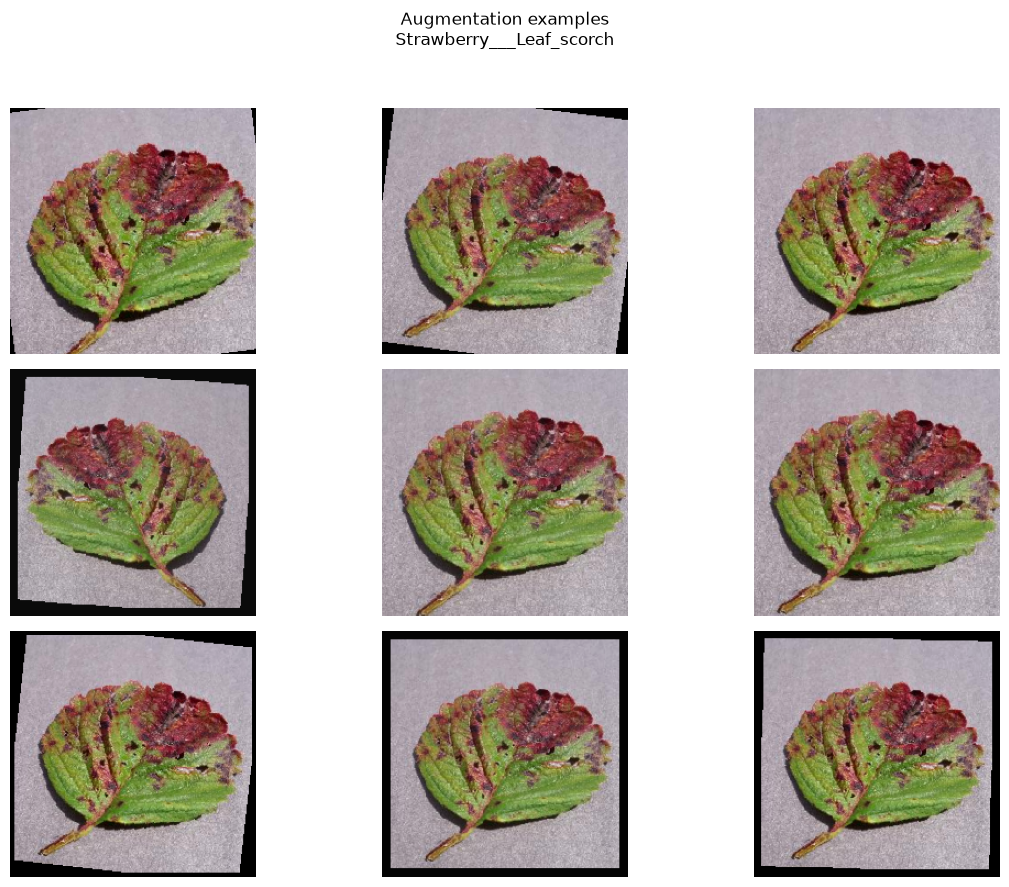

Saved: D:\Plant_disease\plant-disease-classification\outputs\figures\augmentation_examples.png


In [14]:
sample_row = train_split_df.sample(
    1,
    random_state=SEED
).iloc[0]

sample_path = DATA_DIR.joinpath(
    *PurePosixPath(
        sample_row["relative_path"]
    ).parts
)

with Image.open(sample_path) as image:
    source_image = image.convert("RGB")

    plt.figure(figsize=(12, 9))

    for i in range(9):
        augmented = train_transform(
            source_image.copy()
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(
            augmented.permute(1, 2, 0).numpy()
        )
        plt.axis("off")

    plt.suptitle(
        "Augmentation examples\n"
        + sample_row["class_name"],
        fontsize=12
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    augmentation_figure_path = (
        FIGURES_DIR
        / "augmentation_examples.png"
    )

    plt.savefig(
        augmentation_figure_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

print("Saved:", augmentation_figure_path)


# XIII. KIỂM TRA MỘT BATCH SAU XỬ LÝ

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype      : torch.float32
Label dtype      : torch.int64
Pixel range      : 0.0 -> 1.0
Label range      : 1 -> 37


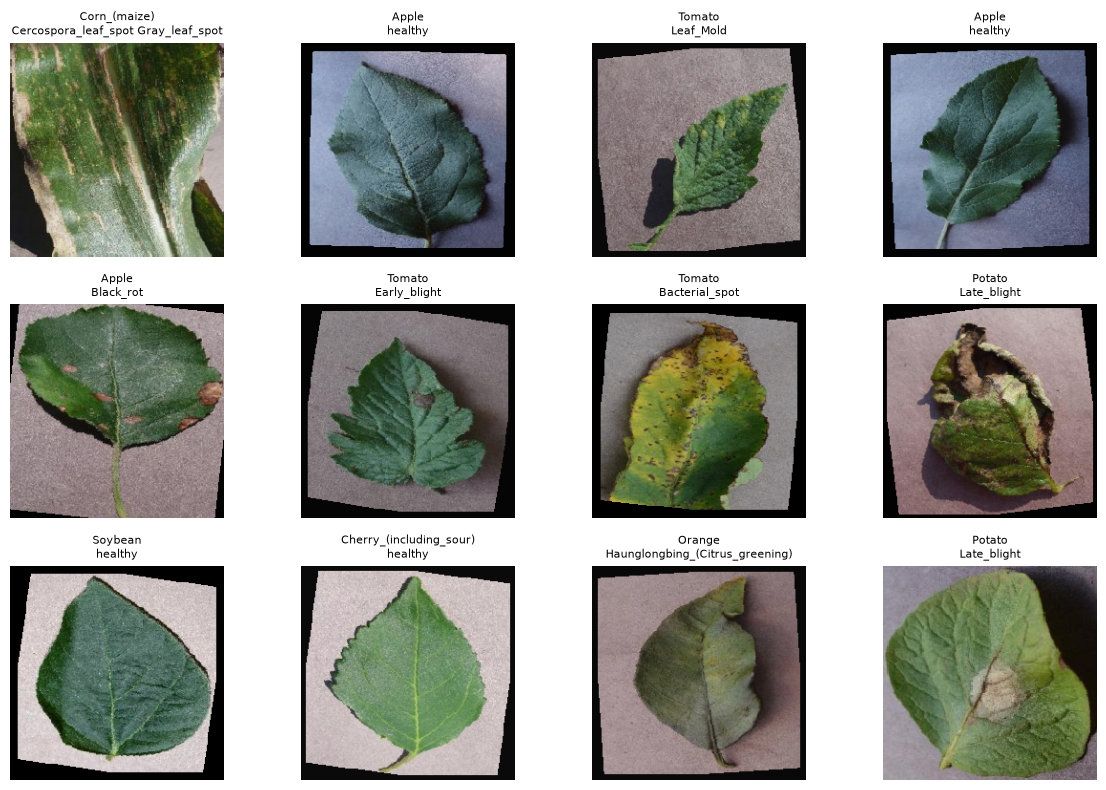

Saved: D:\Plant_disease\plant-disease-classification\outputs\figures\processed_train_batch.png


In [15]:
images, labels = next(
    iter(train_loader)
)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype      :", images.dtype)
print("Label dtype      :", labels.dtype)
print(
    "Pixel range      :",
    float(images.min()),
    "->",
    float(images.max())
)
print(
    "Label range      :",
    int(labels.min()),
    "->",
    int(labels.max())
)

assert images.ndim == 4
assert images.shape[1] == 3
assert images.shape[2] == IMG_SIZE
assert images.shape[3] == IMG_SIZE
assert float(images.min()) >= 0.0
assert float(images.max()) <= 1.0

plt.figure(figsize=(12, 8))

num_show = min(
    12,
    len(images)
)

for i in range(num_show):
    image = (
        images[i]
        .permute(1, 2, 0)
        .numpy()
    )

    label = int(
        labels[i].item()
    )

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        class_names[label]
        .replace("___", "\n"),
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()

batch_figure_path = (
    FIGURES_DIR
    / "processed_train_batch.png"
)

plt.savefig(
    batch_figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", batch_figure_path)


# XIV. TRANSFER LEARNING: QUY TẮC PREPROCESSING

`data_split.csv` và `class_names.json` được dùng chung cho mọi model, nhưng **pixel preprocessing không nhất thiết giống nhau**.

- **Simple/Complex CNN tự xây:** pipeline hiện tại dùng `ToTensor()` → `[0, 1]`.
- **Transfer learning:** trong `05_transfer_learning.ipynb`, hãy lấy preprocessing từ chính pretrained weights, ví dụ với torchvision:

```python
from torchvision.models import ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
pretrained_eval_transform = weights.transforms()
```

Như vậy resize/crop/normalization luôn đúng với model pretrained được chọn, thay vì hard-code một normalization có thể không phù hợp.


# XV. LƯU CLASS ORDER VÀ CẤU HÌNH

In [16]:
# class_names.json: thứ tự cố định dùng chung.
with open(
    CLASS_NAMES_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        class_names,
        file,
        ensure_ascii=False,
        indent=2
    )


split_count_dict = {
    name: int(
        (split_df["split"] == name).sum()
    )
    for name in [
        "train",
        "validation",
        "test"
    ]
}

config = {
    "seed": SEED,
    "image_size": [
        IMG_SIZE,
        IMG_SIZE
    ],
    "batch_size": BATCH_SIZE,
    "num_classes": len(class_names),
    "paths": {
        "metadata": str(
            METADATA_PATH.relative_to(PROJECT_DIR)
        ).replace("\\", "/"),
        "duplicate_issues": str(
            DUPLICATE_PATH.relative_to(PROJECT_DIR)
        ).replace("\\", "/"),
        "near_duplicate_issues": str(
            NEAR_DUPLICATE_PATH.relative_to(PROJECT_DIR)
        ).replace("\\", "/"),
        "data_split": str(
            DATA_SPLIT_PATH.relative_to(PROJECT_DIR)
        ).replace("\\", "/"),
        "class_names": str(
            CLASS_NAMES_PATH.relative_to(PROJECT_DIR)
        ).replace("\\", "/")
    },
    "cleaning": {
        "metadata_rows_before_cleaning": int(
            len(metadata)
        ),
        "broken_images": int(
            len(broken_paths)
        ),
        "missing_files": int(
            len(missing_file_paths)
        ),
        "label_conflict_groups": int(
            len(conflict_groups)
        ),
        "label_conflict_images": int(
            len(label_conflict_df)
        ),
        "exact_duplicate_copies_removed": int(
            len(exact_duplicate_removed)
        ),
        "rows_after_cleaning": int(
            len(clean_df)
        )
    },
    "split_strategy": {
        "test": (
            "All usable original val images; "
            "if a duplicate/near-duplicate group touches original val, "
            "the whole group is assigned to test."
        ),
        "train_validation_source": (
            "Usable original train images not assigned to a test group."
        ),
        "validation_fraction_of_remaining_train": 0.125,
        "splitter": "StratifiedGroupKFold",
        "n_splits": 8,
        "selected_fold": (
            None
            if selected_fold is None
            else int(selected_fold)
        ),
        "stratify_column": "class_name",
        "group_column": "group_id"
    },
    "final_split_counts": split_count_dict,
    "custom_cnn_preprocessing": {
        "color": "RGB",
        "resize": [
            IMG_SIZE,
            IMG_SIZE
        ],
        "pixel_range": [
            0.0,
            1.0
        ],
        "train_augmentation": {
            "horizontal_flip_probability": 0.5,
            "rotation_degrees": 10,
            "zoom_scale": [
                0.90,
                1.10
            ],
            "contrast_jitter": 0.10
        },
        "validation_augmentation": None,
        "test_augmentation": None
    },
    "transfer_learning_preprocessing": (
        "Use the preprocessing/normalization required by the selected "
        "pretrained weights in the transfer-learning notebook."
    )
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        config,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Saved:", DATA_SPLIT_PATH)
print("Saved:", CLASS_NAMES_PATH)
print("Saved:", CONFIG_PATH)


Saved: D:\Plant_disease\plant-disease-classification\outputs\results\data_split.csv
Saved: D:\Plant_disease\plant-disease-classification\outputs\results\class_names.json
Saved: D:\Plant_disease\plant-disease-classification\outputs\results\preprocessing_config.json


# XVI. TỔNG KẾT

In [17]:
print("=" * 65)
print("PREPROCESSING SUMMARY")
print("=" * 65)

print(
    f"Metadata trước làm sạch : {len(metadata):,}"
)
print(
    f"Dữ liệu sau làm sạch    : {len(split_df):,}"
)
print(
    f"Number of classes       : {len(class_names)}"
)

print()

for split_name in [
    "train",
    "validation",
    "test"
]:
    count = int(
        (split_df["split"] == split_name).sum()
    )

    ratio = (
        count / len(split_df)
        if len(split_df) > 0
        else 0
    )

    print(
        f"{split_name:<11}: "
        f"{count:>6,} "
        f"({ratio:.2%})"
    )

print()
print(
    "Group leakage            : 0"
)
print(
    "Near-duplicate leakage   : 0"
)
print(
    "Image size               : "
    f"{IMG_SIZE} x {IMG_SIZE}"
)
print(
    "Custom CNN pixel range   : [0, 1]"
)
print(
    "Train augmentation       : Yes"
)
print(
    "Validation/Test augment  : No"
)

print("\nOutputs:")
print(" -", DATA_SPLIT_PATH)
print(" -", CLASS_NAMES_PATH)
print(" -", CONFIG_PATH)
print(
    " -",
    FIGURES_DIR / "augmentation_examples.png"
)
print(
    " -",
    FIGURES_DIR / "processed_train_batch.png"
)


PREPROCESSING SUMMARY
Metadata trước làm sạch : 54,305
Dữ liệu sau làm sạch    : 54,284
Number of classes       : 38

train      : 37,538 (69.15%)
validation :  5,363 (9.88%)
test       : 11,383 (20.97%)

Group leakage            : 0
Near-duplicate leakage   : 0
Image size               : 224 x 224
Custom CNN pixel range   : [0, 1]
Train augmentation       : Yes
Validation/Test augment  : No

Outputs:
 - D:\Plant_disease\plant-disease-classification\outputs\results\data_split.csv
 - D:\Plant_disease\plant-disease-classification\outputs\results\class_names.json
 - D:\Plant_disease\plant-disease-classification\outputs\results\preprocessing_config.json
 - D:\Plant_disease\plant-disease-classification\outputs\figures\augmentation_examples.png
 - D:\Plant_disease\plant-disease-classification\outputs\figures\processed_train_batch.png


## Output để các notebook model đọc độc lập

Các notebook model **không cần chạy lại notebook này** nếu các file output đã tồn tại.

### `outputs/results/data_split.csv`

Các cột chính:

```text
relative_path
class_name
class_id
split
original_split
group_id
```

### `outputs/results/class_names.json`

Danh sách tên class theo đúng thứ tự `class_id`.

### `outputs/results/preprocessing_config.json`

Lưu seed, kích thước ảnh, batch size, cleaning summary, split strategy và augmentation.

### `outputs/figures/`

Có:

```text
augmentation_examples.png
processed_train_batch.png
```

Ba model sau đó phải đọc lại `data_split.csv` và `class_names.json` thay vì tự chia dữ liệu lần nữa.
